# Домашнее задание №3: ислледование KNN
---
## 1. Первичный анализ данных (описание датасета)
### Star dataset to predict star types

**Ссылка для скачивания:**  
https://www.kaggle.com/datasets/deepu1109/star-dataset?resource=download

### О датасете
- **240 записей**, 6 признаков (4 числовых + 2 категориальных)
- **Целевая переменная:** `Star type` 6 классов: 
    - 0 - Коричневый карлик (Brown Dwarf), 
    - 1 - Красный карлик (Red Dwarf), 
    - 2 - Белый карлик (White Dwarf), 
    - 3 - Главная последовательность (Main Sequence),
    - 4 - Сверхгигант (Supergiant),
    - 5 - Гипергигант (Hypergiant))
- **Описание признаков:**

| Признак | Описание | Тип |
|---------|----------|-----|
| **Temperature (K)** | Абсолютная температура в Кельвинах | Числовой (int) |
| **Luminosity(L/Lo)** | Светимость относительно Солнца | Числовой (float) |
| **Radius(R/Ro)** | Радиус относительно Солнца | Числовой (float) |
| **Absolute magnitude(Mv)** | Абсолютная звёздная величина | Числовой (float) |
| **Star color** | Цвет звезды (white, Red, Blue, Yellow, yellow-orange и др.) | Категориальный (str) |
| **Spectral Class** | Спектральный класс (M, B, O, A, F, K, G) | Категориальный (str) |

- **Пропусков нет - все 240 записей содержат полные данные по всем признакам**
- **Распределение классов:**

| Star Type | Количество |
|:---------:|:--------:|
| 0 | 40 |
| 1 | 40 |
| 2 | 40 |
| 3 | 40 |
| 4 | 40 |
| 5 | 40 |

- **Сбалансированные классы** - по 40 объектов каждого типа

- **Возможные проблемы в данных:**
    - Сильная "Скошенность" распределений (есть выбросы):
        - **Luminosity:** 75% звезд имеют светимость < 198 000, но есть выбросы до 849 420
        - **Radius:** 75% звезд имеют радиус < 42.75, но есть гиганты с радиусом 1948.5

    **Возможное решение:** увеличение параметра k для сглаживания влияния выбросов; взвешенный поиск
    - Разные масштабы признаков:

| Признак | min | max | Размах |
|---------|-----|-----|--------|
| Temperature | 1 939 | 40 000 | ~38 000 |
| Luminosity | 0.00008 | 849 420 | ~850 000 |
| Radius | 0.0084 | 1 948.5 | ~1 948 |
| Absolute magnitude | -11.92 | 20.06 | ~32 |

**Решение:** используем масштабирование признаков (StandardScaler или MinMaxScaler), приводя все признаки к одному масштабу.

- **Структура данных:**

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("6 class csv.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    str    
 6   Spectral Class          240 non-null    str    
dtypes: float64(3), int64(2), str(2)
memory usage: 13.3 KB


**Первые 10 строк**

In [184]:
df.head(10)

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
5,2840,0.000650,0.1100,16.98,0,Red,M
6,2637,0.000730,0.1270,17.22,0,Red,M
7,2600,0.000400,0.0960,17.40,0,Red,M
8,2650,0.000690,0.1100,17.45,0,Red,M
9,2700,0.000180,0.1300,16.05,0,Red,M


- **Базовые статистики:**

In [185]:
df.describe()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


- **Баланс классов:**

Распределение классов целевой переменной Star type:


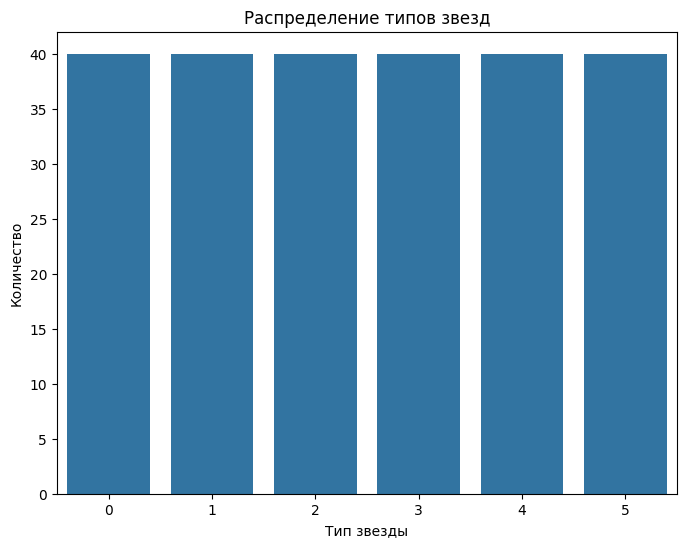

Star type
0    40
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64

In [186]:
print(f"Распределение классов целевой переменной Star type:")

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Star type')
plt.title('Распределение типов звезд')
plt.xlabel('Тип звезды')
plt.ylabel('Количество')
plt.show()

df["Star type"].value_counts()

Распределение классов Star color:


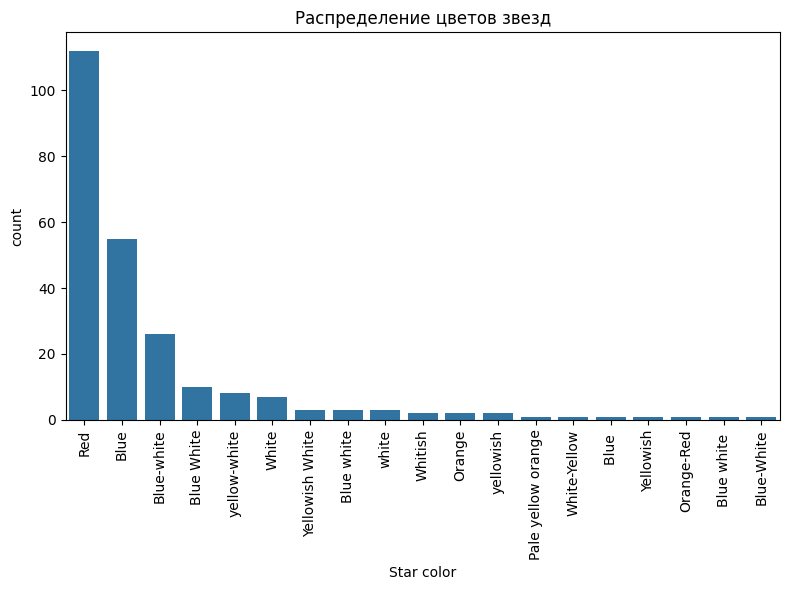

Star color
Red                   112
Blue                   55
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Yellowish White         3
Blue white              3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Blue                    1
Yellowish               1
Orange-Red              1
Blue white              1
Blue-White              1
Name: count, dtype: int64

In [187]:
print(f"Распределение классов Star color:")

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Star color',
              order=df['Star color'].value_counts().index)
plt.title('Распределение цветов звезд')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

df["Star color"].value_counts()

Некоторые цвета просто повторяются, только разная запись, поэтому их нужно почистить.
Красный, синий, сине-белый, желто-белый и белый - наиболее наблюдаемые цвета.

In [188]:
df.replace({"Star color" : {"Blue-white" : "Blue-White", 
                                  "Blue White" : "Blue-White", 
                                  "Blue white" : "Blue-White", 
                                  "Blue white " : "Blue-White", 
                                  "Blue-White" : "Blue-White",
                                  "yellow-white" : "Yellow-White",
                                  "Yellowish White" : "Yellow-White",
                                  "yellowish" : "Yellow-White",
                                  "White-Yellow" : "Yellow-White",
                                  "Yellowish" : "Yellow-White",
                                  "white" : "White",
                                  "Whitish" : "White",
                                  "Blue " : "Blue",
                                  "Pale yellow orange" : "Red",
                                  "Orange" : "Red",
                                  "Orange-Red" : "Red"}},
                                  inplace = True);

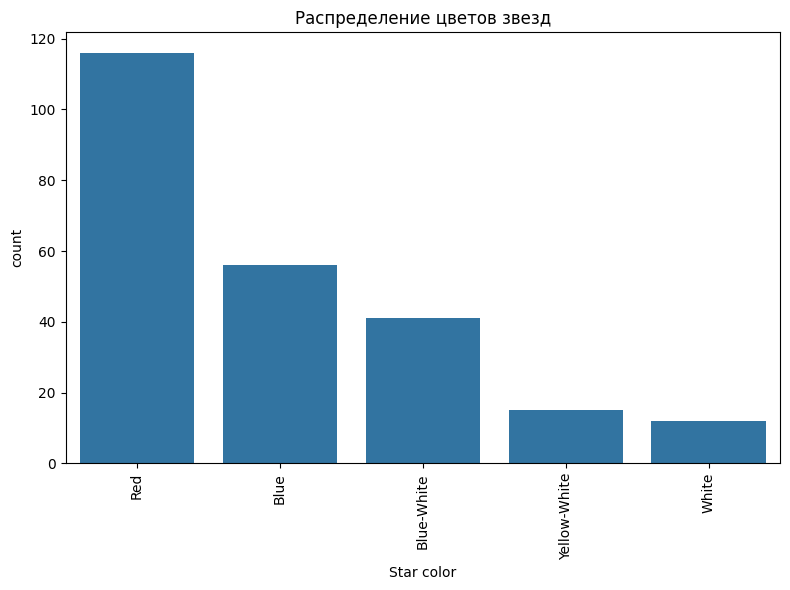

Star color
Red             116
Blue             56
Blue-White       41
Yellow-White     15
White            12
Name: count, dtype: int64

In [189]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Star color',
              order=df['Star color'].value_counts().index)
plt.title('Распределение цветов звезд')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

df['Star color'].value_counts()

Распределение классов Spectral Class:


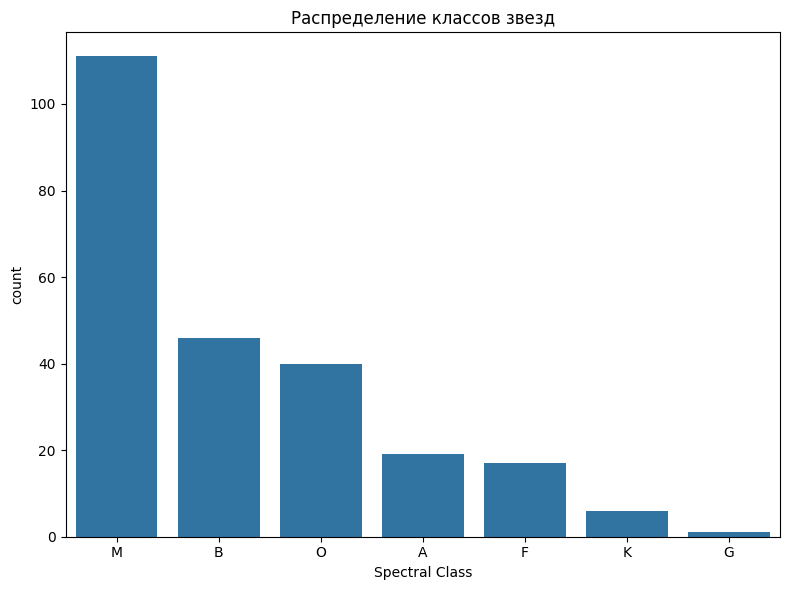

Spectral Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

In [190]:
print(f"Распределение классов Spectral Class:")

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Spectral Class',
              order=df['Spectral Class'].value_counts().index)
plt.title('Распределение классов звезд')
plt.tight_layout()
plt.show()

df["Spectral Class"].value_counts()

--- 
## 2. Подготовка данных

**Кодирование категориальных признаков**

In [191]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)

print("После кодирования:")
df.head()

После кодирования:


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color_Blue,Star color_Blue-White,Star color_Red,Star color_White,Star color_Yellow-White,Spectral Class_A,Spectral Class_B,Spectral Class_F,Spectral Class_G,Spectral Class_K,Spectral Class_M,Spectral Class_O
0,3068,0.002400,0.1700,16.12,0,0,0,1,0,0,0,0,0,0,0,1,0
1,3042,0.000500,0.1542,16.60,0,0,0,1,0,0,0,0,0,0,0,1,0
2,2600,0.000300,0.1020,18.70,0,0,0,1,0,0,0,0,0,0,0,1,0
3,2800,0.000200,0.1600,16.65,0,0,0,1,0,0,0,0,0,0,0,1,0
4,1939,0.000138,0.1030,20.06,0,0,0,1,0,0,0,0,0,0,0,1,0


**Построим матрицу корреляции и выведем топ-признаки**

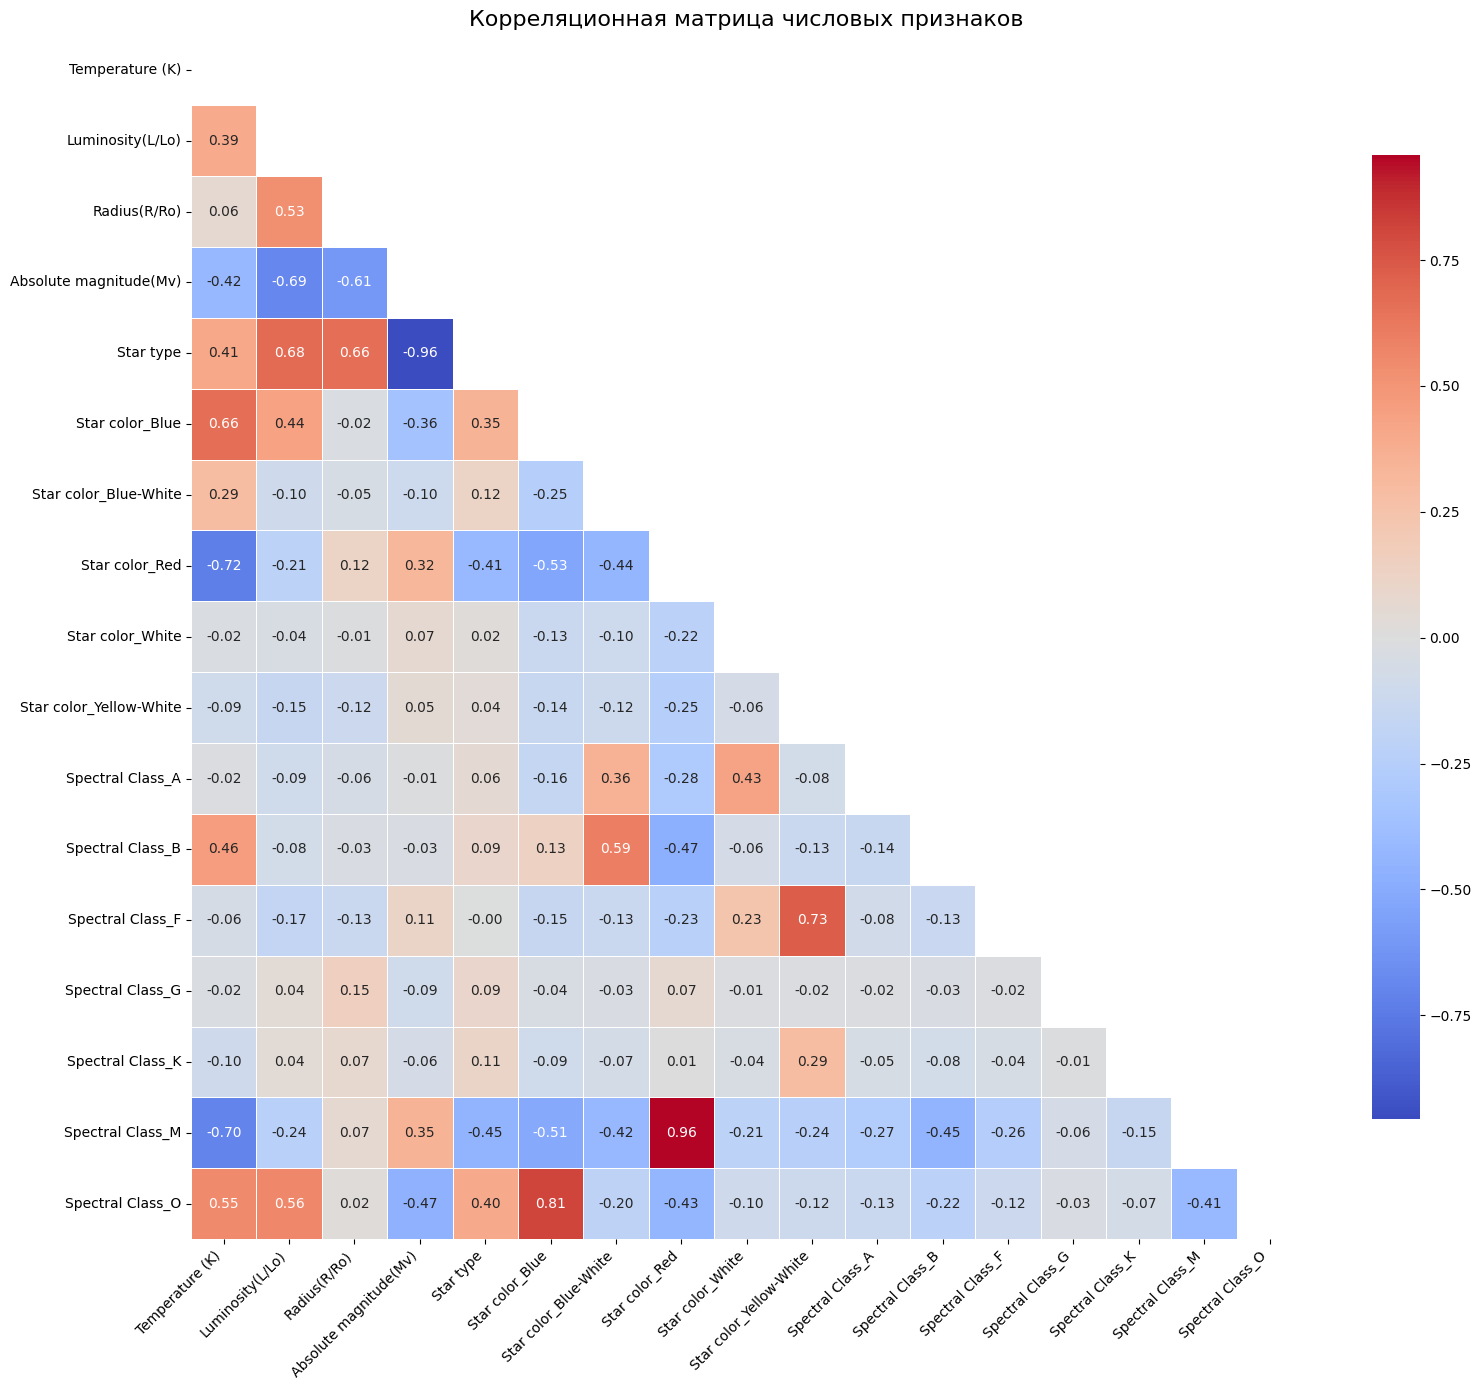

In [192]:
# Построение корреляционной матрицы
plt.figure(figsize=(16, 14))

correlation_matrix = df.select_dtypes(include=[np.number]).corr()

mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица числовых признаков', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Корреляция признаков с целевой переменной:
Star type                  1.000000
Luminosity(L/Lo)           0.676845
Radius(R/Ro)               0.660975
Temperature (K)            0.411129
Spectral Class_O           0.399339
Star color_Blue            0.346103
Star color_Blue-White      0.119925
Spectral Class_K           0.109388
Spectral Class_G           0.094689
Spectral Class_B           0.092975
Spectral Class_A           0.058735
Star color_Yellow-White    0.035277
Star color_White           0.022389
Spectral Class_F          -0.004755
Star color_Red            -0.410106
Spectral Class_M          -0.447735
Absolute magnitude(Mv)    -0.955276
Name: Star type, dtype: float64


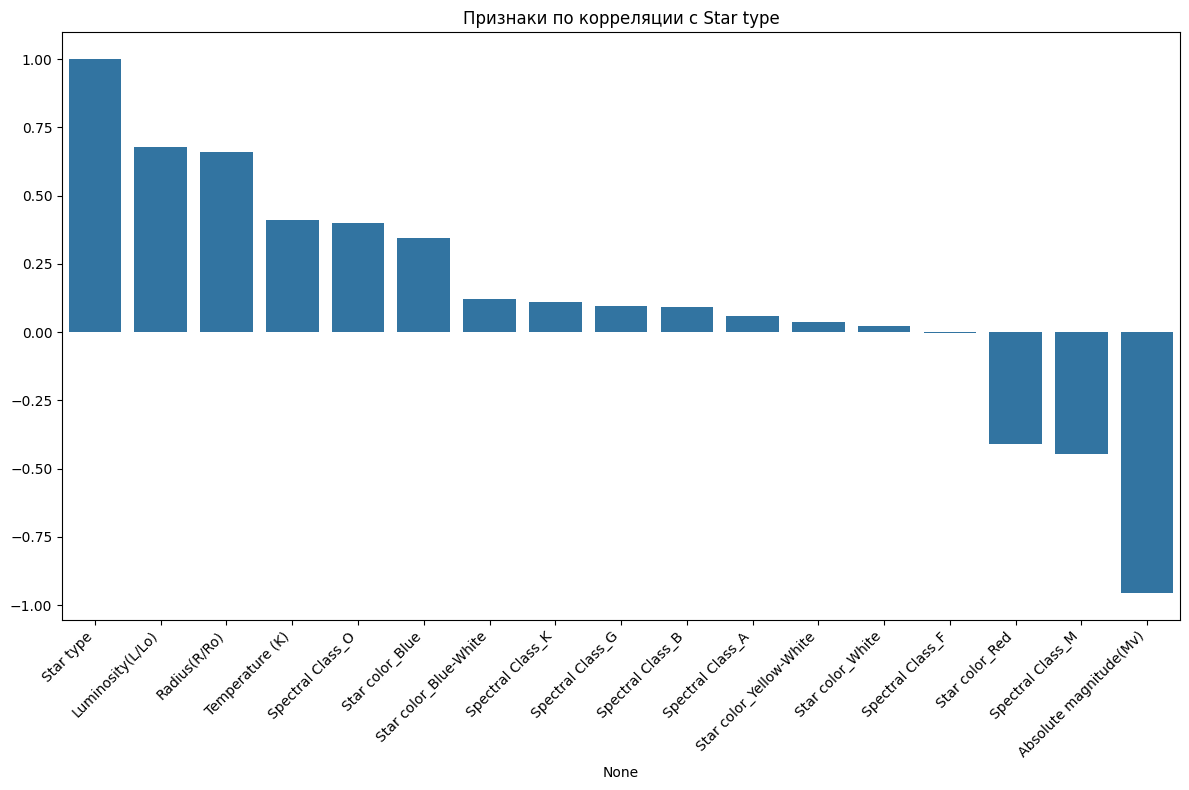

In [193]:
# Расчет корреляции признаков с целевой переменной
target_correlation = correlation_matrix['Star type'].sort_values(ascending=False)
print("\nКорреляция признаков с целевой переменной:")
print(target_correlation)

# Визуализация топ-10 признаков по корреляции с целевой переменной
plt.figure(figsize=(12, 8))
sns.barplot(x=target_correlation.index[:], y=target_correlation.values[:])
plt.title('Признаки по корреляции с Star type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Как видим из матрицы корреляций, наиболее сильную связь с типом звезды имеют:
- `Absolute magnitude(Mv)` - **-0.955**
- `Luminosity(L/Lo)` - **+0.677**
- `Radius(R/Ro)` - **+0.661**
- `Temperature(K)` - **+0.411**

Эти четыре признака имеют ясный физический смысл и определяют положение звезды на диаграмме Герцшпрунга-Рассела, поэтому они будут основой для нашей модели. Остальные признаки (цвет и спектральный класс) являются производными от этих характеристик, поэтому их можно исключить.

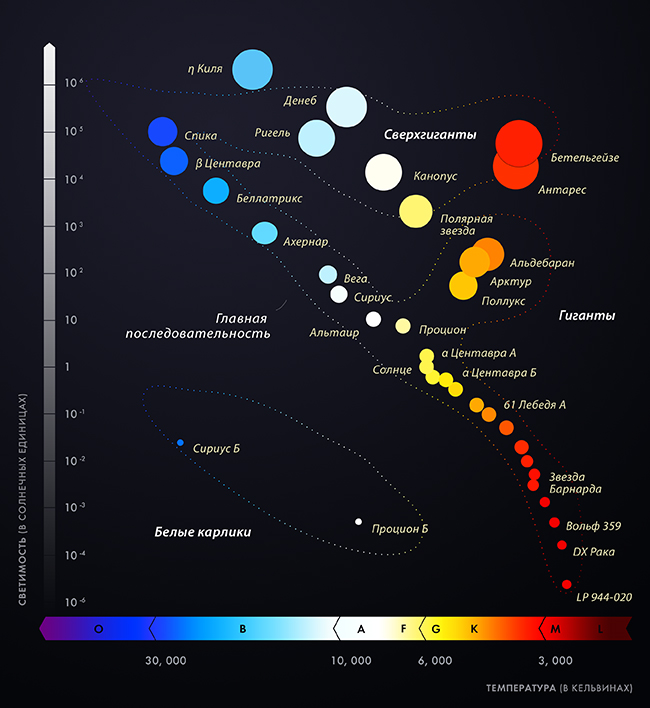\
**Диаграмма Герцшпрунга-Рассела**

In [194]:
needed_columns = ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 
                  'Absolute magnitude(Mv)', 'Star type']

df = df[needed_columns]

**Разделение на train / test**

In [195]:
X = df.drop("Star type", axis=1)
y = df["Star type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Масштабирование**

In [196]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Почему масштабирование важно для KNN**

KNN использует расстояния. Без масштабирования признаки с большими значениями (Luminosity (850000), Radius (1948)) доминируют над признаками с малыми значениями (Absolute magnitude (32)). Масштабирование `StandardScaler` дает всем признакам равный вес.

**Почему нельзя подбирать параметры на тестовой выборке**

Когда мы подбираем гиперпараметры модели (например, количество соседей `k` в KNN) на тестовых данных, мы неявно "обучаем" модель на этих данных. Тестовая выборка служит для финальной объективной оценки качества обученной модели. Использование тестовой выборки в процессе подбора параметров нарушает чистоту эксперимента, поскольку модель получает информацию о данных, которые должны оставаться неизвестными до завершения обучения. В результате оценка на тестовой выборке перестаёт быть объективной: она отражает не способность модели обобщать закономерности на новые данные, а её подстройку под конкретные примеры из теста.

---
## 3. Обучение KNN 

**Разные значения параметра `n_neighbors`**

In [197]:
k_range = range(1, 31, 2)
train_scores_k = []
test_scores_k = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights="uniform", metric="euclidean")
    knn.fit(X_train_scaled, y_train)
    train_scores_k.append(knn.score(X_train_scaled, y_train))
    test_scores_k.append(knn.score(X_test_scaled, y_test))
    print(f"K={k}: Train={train_scores_k[-1]:.3f}, Test={test_scores_k[-1]:.3f}")

best_k_idx = np.argmax(test_scores_k)
best_k = k_range[best_k_idx]
print(f"\nЛучшее K: {best_k} с точностью {test_scores_k[best_k_idx]:.3f}")

K=1: Train=1.000, Test=0.979
K=3: Train=0.995, Test=0.979
K=5: Train=0.990, Test=0.958
K=7: Train=0.990, Test=0.958
K=9: Train=0.990, Test=1.000
K=11: Train=1.000, Test=1.000
K=13: Train=0.979, Test=1.000
K=15: Train=0.979, Test=1.000
K=17: Train=0.974, Test=1.000
K=19: Train=0.958, Test=1.000
K=21: Train=0.964, Test=1.000
K=23: Train=0.964, Test=1.000
K=25: Train=0.953, Test=0.958
K=27: Train=0.948, Test=0.938
K=29: Train=0.927, Test=0.917

Лучшее K: 9 с точностью 1.000


**Комментарий:**
Лучшим является K=9. При малых K (1-3) модель показывает высокую точность на обучающей выборке, но может быть чувствительна к шуму и склонна к переобучению. При увеличении K до 9–11 качество стабилизируется на максимальном уровне, а при K>13 начинает постепенно снижаться.

**Сравнение типов весов (`uniform`, `distance`)**

In [198]:
weights = ["uniform", "distance"]
train_scores_w = []
test_scores_w = []

for w in weights:
    knn = KNeighborsClassifier(n_neighbors=9, weights=w, metric="euclidean")
    knn.fit(X_train_scaled, y_train)
    train_scores_w.append(knn.score(X_train_scaled, y_train))
    test_scores_w.append(knn.score(X_test_scaled, y_test))
    print(f"w={w}: Train={train_scores_w[-1]:.3f}, Test={test_scores_w[-1]:.3f}")

w=uniform: Train=0.990, Test=1.000
w=distance: Train=1.000, Test=1.000


**Комментарий:**
Оба подхода дают отличные результаты. Для данного набора данных выбор типа весов не критичен.

**Сравнение разных метрик расстояния (`euclidean`, `manhattan`, `minkowski`)**

In [199]:
metrics = ["euclidean", "manhattan", "minkowski"]
train_scores_m = []
test_scores_m = []

for m in metrics:
    knn = KNeighborsClassifier(n_neighbors=9, weights="uniform", metric=m)
    knn.fit(X_train_scaled, y_train)
    train_scores_m.append(knn.score(X_train_scaled, y_train))
    test_scores_m.append(knn.score(X_test_scaled, y_test))
    print(f"m={m}: Train={train_scores_m[-1]:.3f}, Test={test_scores_m[-1]:.3f}")

m=euclidean: Train=0.990, Test=1.000
m=manhattan: Train=0.995, Test=0.979
m=minkowski: Train=0.990, Test=1.000


**Комментарий:**
Анализ различных метрик расстояния показал, что Euclidean и Minkowski (с параметром p=2, который идентичен Euclidean) обеспечивают максимальную точность (100% на тесте). Manhattan показала более низкий результат (97,9%), что может объясняться её меньшей чувствительностью к выбросам - в датасете звезды-гиганты являются важными "выбросами", которые Manhattan метрика может сглаживать.

**Общий важный комментарий:**
Данные результаты получены при фиксированном разбиении train/test. Для более надежного выбора гиперпараметров далее будет использована кросс-валидация, которая позволит оценить устойчивость результатов на разных подвыборках данных.

---
## 4. Подбор гиперпараметров 

In [200]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность на CV: {grid_search.best_score_:.4f}")
print(f"Точность на тесте: {grid_search.score(X_test_scaled, y_test):.4f}")

Fitting 5 folds for each of 42 candidates, totalling 210 fits
Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Лучшая точность на CV: 0.9949
Точность на тесте: 0.9583


**Комментарий:**
Наилучшие параметры KNN: K=5, метрика euclidean, веса uniform. Модель достигла точности 96% на тестовой выборке (48 звезд).

Анализ ошибок показал:
- 4 класса (0, 1, 2, 5) классифицируются идеально (100%).
- Проблемы возникают только между сверхгигантами (класс 4) и звездами главной последовательности (класс 3) - допущено 2 ошибки.

Это объясняется физической близостью этих типов звезд в пространстве признаков (температура, светимость, радиус). В целом модель демонстрирует хорошее качество.

**Проверка влияния масштабирования**

In [201]:
knn_no_scale = KNeighborsClassifier(**grid_search.best_params_)
knn_no_scale.fit(X_train, y_train)

cv_scores_no_scale = cross_val_score(knn_no_scale, X_train, y_train, cv=5)
print("Без масштабирования:")
print(f"Точность на CV: {cv_scores_no_scale.mean():.4f}")
print(f"Точность на тесте: {knn_no_scale.score(X_test, y_test):.4f}")

print("\nС масштабированием:")
print(f"Точность на CV: {grid_search.best_score_:.4f}")
print(f"Точность на тесте: {grid_search.score(X_test_scaled, y_test):.4f}")

Без масштабирования:
Точность на CV: 0.6144
Точность на тесте: 0.6875

С масштабированием:
Точность на CV: 0.9949
Точность на тесте: 0.9583


**Комментарий:**
Как видим, масштабирование дейсвительно важно для KNN, так как без него, признами с большими значениями модель считает более важными, что приводит к ошибкам в предсказании.

---
## 5. Отчет лучшей модели

Параметры: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Отчет по классам:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       0.80      1.00      0.89         8
           4       1.00      0.75      0.86         8
           5       1.00      1.00      1.00         8

    accuracy                           0.96        48
   macro avg       0.97      0.96      0.96        48
weighted avg       0.97      0.96      0.96        48



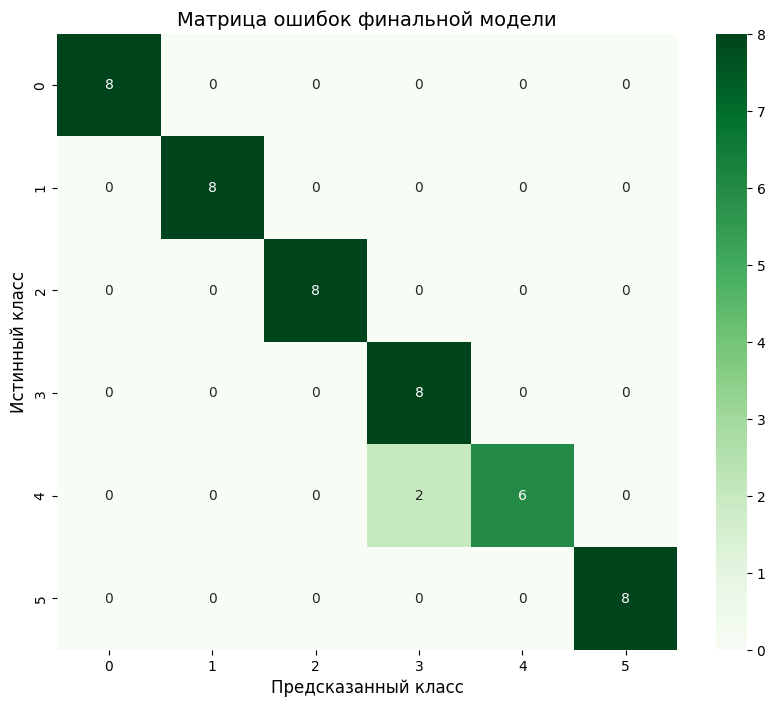

Соответствие цифр типам звезд:
  0 -> Коричневый карлик (Brown Dwarf)
  1 -> Красный карлик (Red Dwarf)
  2 -> Белый карлик (White Dwarf)
  3 -> Главная последовательность (Main Sequence)
  4 -> Сверхгигант (Supergiant)
  5 -> Гипергигант (Hypergiant)


In [202]:
best_knn = grid_search.best_estimator_

y_pred = best_knn.predict(X_test_scaled)

print(f"Параметры: {grid_search.best_params_}")
print("Отчет по классам:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(10, 8))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))

plt.title('Матрица ошибок финальной модели', fontsize=14)
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.show()

class_names = {
    0: 'Коричневый карлик (Brown Dwarf)',
    1: 'Красный карлик (Red Dwarf)', 
    2: 'Белый карлик (White Dwarf)',
    3: 'Главная последовательность (Main Sequence)',
    4: 'Сверхгигант (Supergiant)',
    5: 'Гипергигант (Hypergiant)'
}

print("Соответствие цифр типам звезд:")
for code, name in class_names.items():
    print(f"  {code} -> {name}")

**Комментарий:**
Наилучшие параметры KNN: K=5, метрика euclidean, веса uniform. Модель достигла точности 96% на тестовой выборке (48 звезд).

Анализ ошибок показал:
- 4 класса (0,1,2,5) классифицируются идеально (100%)
- Проблемы возникают только между сверхгигантами (класс 4) и звездами главной последовательности (класс 3) - 2 ошибки

Это объясняется физической близостью этих типов звезд в пространстве признаков (температура, светимость, радиус). В целом модель демонстрирует хорошее качество.

---
## 6. Выводы

Метод KNN наиболее точно описывается фразой "скажи мне, кто твой друг, и я скажу, кто ты". На примере датасета для классификации звёзд было проведено:

- **Описание датасета, первичный анализ данных**: небольшой размер (240 записей) идеален для KNN, так как методу необходимо хранить все данные сразу для предсказания. Небольшое количество признаков и отсутствие пропусков упрощает интерпретацию. Сбалансированные классы способствуют высоким показателям точности итоговой модели.
- **Подготовка данных**: на основе матрицы корреляции были выбраны топ-признаки, что ещё улучшило качество модели. Все признаки хорошо описывают физические свойства объекта предсказания, что делает модель крайне простой для понимания. Проведено важное для KNN масштабирование данных.
- **Исследование влияния различных параметров на модель**:
    - Количество ближайших соседей регулирует чувствительность модели к шуму и выбросам. В целом, значений 3–5 обычно достаточно для стандартных ситуаций.
    - Веса в данной модели роли не сыграли, так как простота данных не требует взвешенного поиска.
    - Метрика тоже базовая - евклидова.
- **Подбор гиперпараметров с помощью кросс-валидации** - наиболее правильный метод, так как модель не видит тестовые данные до последнего момента, что корректно с точки зрения обучения.
- **Реализация модели** с подобранными параметрами показала высокую точность (96%) на тестовой выборке. Все классы, кроме близких по физическим параметрам, определены корректно.

KNN показал себя как простой, понятный метод, который подходит для простых задач в машинном обучении.

---
## Бонус: визуализация диаграммы Герцшпрунга-Рассела :)

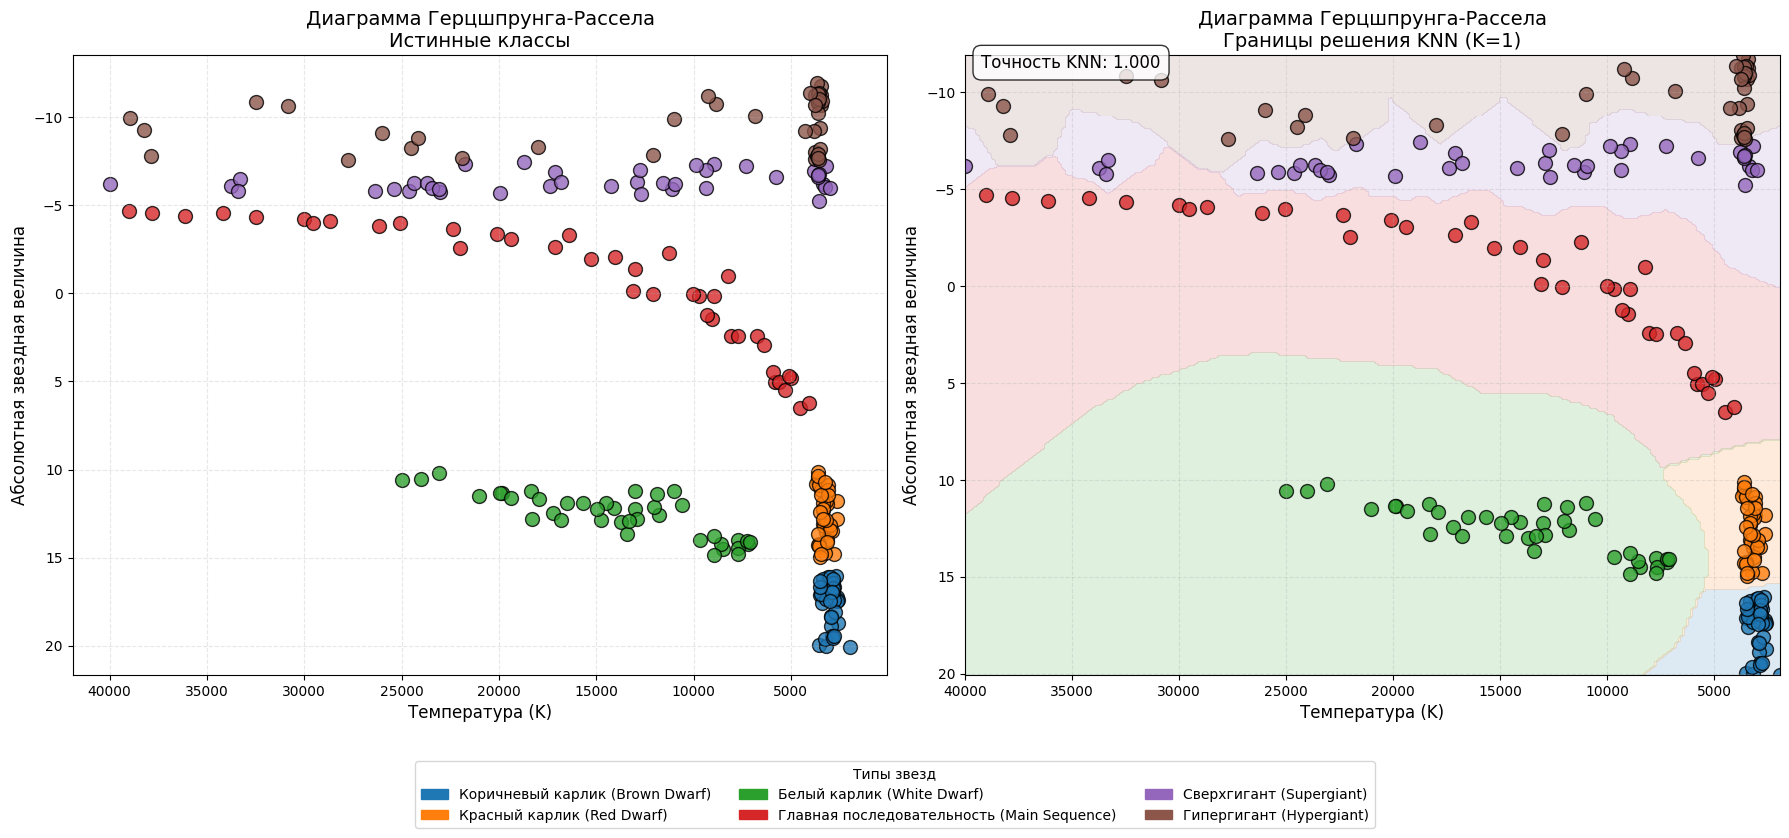

In [203]:
from matplotlib.patches import Patch

hr_data = df.copy()

class_names = {
    0: 'Коричневый карлик (Brown Dwarf)',
    1: 'Красный карлик (Red Dwarf)', 
    2: 'Белый карлик (White Dwarf)',
    3: 'Главная последовательность (Main Sequence)',
    4: 'Сверхгигант (Supergiant)',
    5: 'Гипергигант (Hypergiant)'
}
hr_data['Star type name'] = hr_data['Star type'].map(class_names)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
color_map = {0: colors[0], 1: colors[1], 2: colors[2], 
             3: colors[3], 4: colors[4], 5: colors[5]}

scaler_hr = StandardScaler()
X_hr = df[['Temperature (K)', 'Absolute magnitude(Mv)']].values
X_hr_scaled = scaler_hr.fit_transform(X_hr)

knn_hr = KNeighborsClassifier(n_neighbors=1)
knn_hr.fit(X_hr_scaled, df['Star type'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

for star_type in range(6):
    mask = hr_data['Star type'] == star_type
    ax1.scatter(hr_data.loc[mask, 'Temperature (K)'], 
                hr_data.loc[mask, 'Absolute magnitude(Mv)'],
                c=color_map[star_type], s=100, label=class_names[star_type],
                edgecolor='black', linewidth=1, alpha=0.8)

ax1.set_xlabel('Температура (K)', fontsize=12)
ax1.set_ylabel('Абсолютная звездная величина', fontsize=12)
ax1.set_title('Диаграмма Герцшпрунга-Рассела\nИстинные классы', fontsize=14)
ax1.invert_xaxis()
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, linestyle='--')

temp_grid = np.linspace(df['Temperature (K)'].max(), df['Temperature (K)'].min(), 200)
mag_grid = np.linspace(df['Absolute magnitude(Mv)'].min(), df['Absolute magnitude(Mv)'].max(), 200)
TT, MM = np.meshgrid(temp_grid, mag_grid)

grid_points = np.c_[TT.ravel(), MM.ravel()]
grid_points_scaled = scaler_hr.transform(grid_points)

Z = knn_hr.predict(grid_points_scaled)
Z = Z.reshape(TT.shape)

ax2.contourf(TT, MM, Z, alpha=0.15, colors=colors, levels=np.arange(7)-0.5)

for star_type in range(6):
    mask = hr_data['Star type'] == star_type
    ax2.scatter(hr_data.loc[mask, 'Temperature (K)'], 
                hr_data.loc[mask, 'Absolute magnitude(Mv)'],
                c=color_map[star_type], s=100, label=class_names[star_type],
                edgecolor='black', linewidth=1, alpha=0.8)

ax2.set_xlabel('Температура (K)', fontsize=12)
ax2.set_ylabel('Абсолютная звездная величина', fontsize=12)
ax2.set_title('Диаграмма Герцшпрунга-Рассела\nГраницы решения KNN (K=1)', fontsize=14)
ax2.invert_xaxis()
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, linestyle='--')

accuracy = knn_hr.score(X_hr_scaled, df['Star type'])
ax2.text(0.02, 0.98, f'Точность KNN: {accuracy:.3f}', 
         transform=ax2.transAxes, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', 
                   boxstyle='round,pad=0.5'))

handles = [Patch(color=colors[i], label=class_names[i]) for i in range(6)]
fig.legend(handles=handles, title="Типы звезд", 
          loc='lower center', bbox_to_anchor=(0.5, -0.05),
          ncol=3, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()